# Train a MNIST neural network

The objective is to train a neural network to predict the value of a hand-written digit. The MNIST dataset consists of 60,000 training examples and 10,000 test examples of 28x28 grayscale images, representing digits 0 to 9.

## Dependencies

In [1]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Load the MNIST dataset

Images are converted to tensors and their pixel values are normalized to have a mean of 0.5 and standard deviation of 0.5.

- **transforms.Compose**: A sequence of transformations to apply to the images.
- **ToTensor()**: Converts images into PyTorch tensors.
- **Normalize()**: Normalizes the pixel values to the range [-1, 1].
- **DataLoader**: Handles batching, shuffling, and loading of data.
- **batch_size=64**: 64 samples are processed at once.
- **Validation split**: 15% of the training set is held out as a validation set. Tracking validation loss alongside training loss reveals whether the model is overfitting.

In [2]:
from torch.utils.data import random_split

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,)),
])

train_dataset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# Reserve 15% of training data as a validation set
train_size = int(0.85 * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_subset,   batch_size=64, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
print(f"Train dataset has {len(train_dataset)} images")
print(f"Test dataset has {len(test_dataset)} images")

Train dataset has 60000 images
Test dataset has 10000 images


In [4]:
print(f"Image shape: {train_dataset[0][0].shape}")

Image shape: torch.Size([1, 28, 28])


### Visualize samples

Display a random 3×3 grid of training images to sanity-check the data loading and normalization.

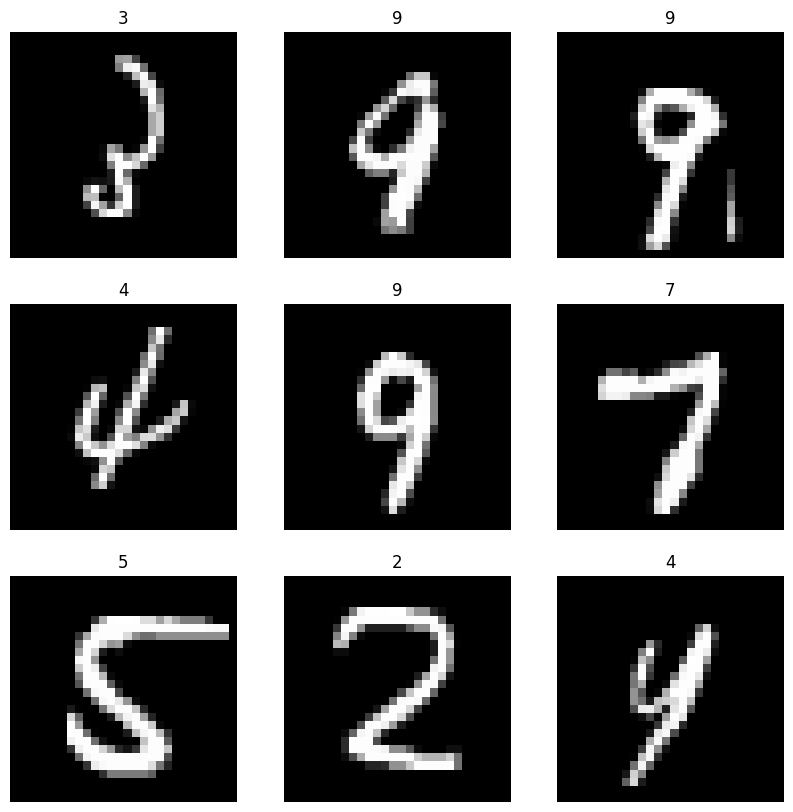

In [5]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
for ax in axes.flatten():
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    image, label = train_dataset[sample_idx]
    ax.set_title(label)
    ax.axis('off')
    ax.imshow(image.squeeze(), cmap='gray')
plt.show()

## Build the model

A feedforward neural network with two hidden layers and dropout regularization.

- **torch.nn.Module**: Base class for all PyTorch models.
- **torch.nn.Linear**: Fully connected layer — every input connects to every output.
- **fc1** (784 → 256): Expands the flattened 28×28 image into a richer representation.
- **Dropout(0.3)**: Randomly zeroes 30% of neurons during training, forcing the network to learn redundant representations and reducing overfitting.
- **fc2** (256 → 128): Second hidden layer for deeper feature extraction.
- **fc3** (128 → 10): Output layer — one logit per digit class (0–9).
- **ReLU**: Applied after each hidden layer to introduce non-linearity; without it, stacking linear layers collapses into a single linear transformation.

In [6]:
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1     = torch.nn.Linear(28 * 28, 256)
        self.dropout = torch.nn.Dropout(0.3)
        self.fc2     = torch.nn.Linear(256, 128)
        self.fc3     = torch.nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = Net()

## Define the Loss Function and Optimizer

- CrossEntropyLoss: Measures the difference between the predicted and true labels and is used for multi-class classification.
- Adam: A popular optimization algorithm that adapts the learning rate during training.
- lr=0.001 sets the learning rate which determines how much we adjust the weights during each update.

In [7]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Train the model

For each epoch, run a full pass over the training batches then evaluate on the validation set.

- **optimizer.zero_grad()**: Clears gradients from the previous iteration — without this, gradients accumulate across batches.
- **loss.backward()**: Computes gradients for each model parameter via backpropagation.
- **optimizer.step()**: Updates the model's weights based on the computed gradients.
- **model.train() / model.eval()**: Switches dropout on (training) and off (evaluation) at the right times.
- **device**: Moves data and model to GPU if available, otherwise CPU.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

train_losses = []
val_losses   = []

num_epochs = 5
for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_loss   = 0.0
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader, 0):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss   += loss.item()

        if i % 100 == 99:
            print(f'[Epoch {epoch+1}, Batch {i+1}] Loss: {running_loss / 100:.4f}')
            running_loss = 0.0

    train_losses.append(epoch_loss / len(train_loader))

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
    val_losses.append(val_loss / len(val_loader))

    print(f'Epoch {epoch+1} — train loss: {train_losses[-1]:.4f}, val loss: {val_losses[-1]:.4f}\n')

[Epoch 1, Batch 100] Loss: 0.9955
[Epoch 1, Batch 200] Loss: 0.4846
[Epoch 1, Batch 300] Loss: 0.3900
[Epoch 1, Batch 400] Loss: 0.3388
[Epoch 1, Batch 500] Loss: 0.3339
[Epoch 1, Batch 600] Loss: 0.3156
[Epoch 1, Batch 700] Loss: 0.2632
Epoch 1 — train loss: 0.4234, val loss: 0.2282

[Epoch 2, Batch 100] Loss: 0.2317
[Epoch 2, Batch 200] Loss: 0.2519
[Epoch 2, Batch 300] Loss: 0.2177
[Epoch 2, Batch 400] Loss: 0.2257
[Epoch 2, Batch 500] Loss: 0.2055
[Epoch 2, Batch 600] Loss: 0.2033
[Epoch 2, Batch 700] Loss: 0.2046
Epoch 2 — train loss: 0.2149, val loss: 0.1488

[Epoch 3, Batch 100] Loss: 0.1875
[Epoch 3, Batch 200] Loss: 0.1779
[Epoch 3, Batch 300] Loss: 0.1861
[Epoch 3, Batch 400] Loss: 0.1808
[Epoch 3, Batch 500] Loss: 0.1812
[Epoch 3, Batch 600] Loss: 0.1811
[Epoch 3, Batch 700] Loss: 0.1695
Epoch 3 — train loss: 0.1797, val loss: 0.1306

[Epoch 4, Batch 100] Loss: 0.1558
[Epoch 4, Batch 200] Loss: 0.1805
[Epoch 4, Batch 300] Loss: 0.1734
[Epoch 4, Batch 400] Loss: 0.1430
[Epoch

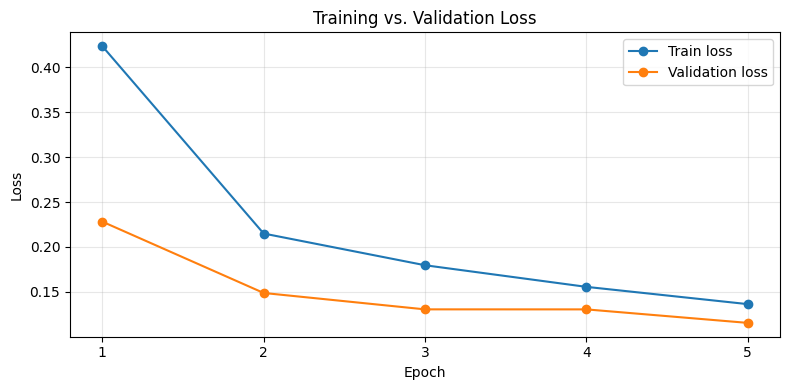

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Train loss')
plt.plot(range(1, num_epochs + 1), val_losses,   marker='o', label='Validation loss')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluate the model

Evaluate on the held-out test set, collecting predictions for the confusion matrix, per-class accuracy breakdown, and misclassified example visualization.

- **model.eval()**: Disables dropout so all neurons contribute to inference.
- **torch.no_grad()**: Skips gradient computation, saving memory during evaluation.

In [10]:
model.eval()
correct = 0
total   = 0

all_labels      = []
all_predictions = []
misclassified   = []  # (image, true_label, predicted_label)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

        # Collect misclassified examples
        mask = predicted != labels
        for img, true, pred in zip(images[mask], labels[mask], predicted[mask]):
            misclassified.append((img.cpu(), true.item(), pred.item()))

print(f'Overall accuracy: {100 * correct / total:.2f}%\n')

# Per-class accuracy
class_correct = [0] * 10
class_total   = [0] * 10
for true, pred in zip(all_labels, all_predictions):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

print('Per-class accuracy:')
for i in range(10):
    print(f'  Digit {i}: {100 * class_correct[i] / class_total[i]:.1f}%  ({class_correct[i]}/{class_total[i]})')

Overall accuracy: 96.65%

Per-class accuracy:
  Digit 0: 99.0%  (970/980)
  Digit 1: 98.9%  (1123/1135)
  Digit 2: 97.1%  (1002/1032)
  Digit 3: 95.8%  (968/1010)
  Digit 4: 96.1%  (944/982)
  Digit 5: 95.2%  (849/892)
  Digit 6: 95.2%  (912/958)
  Digit 7: 95.6%  (983/1028)
  Digit 8: 95.6%  (931/974)
  Digit 9: 97.4%  (983/1009)


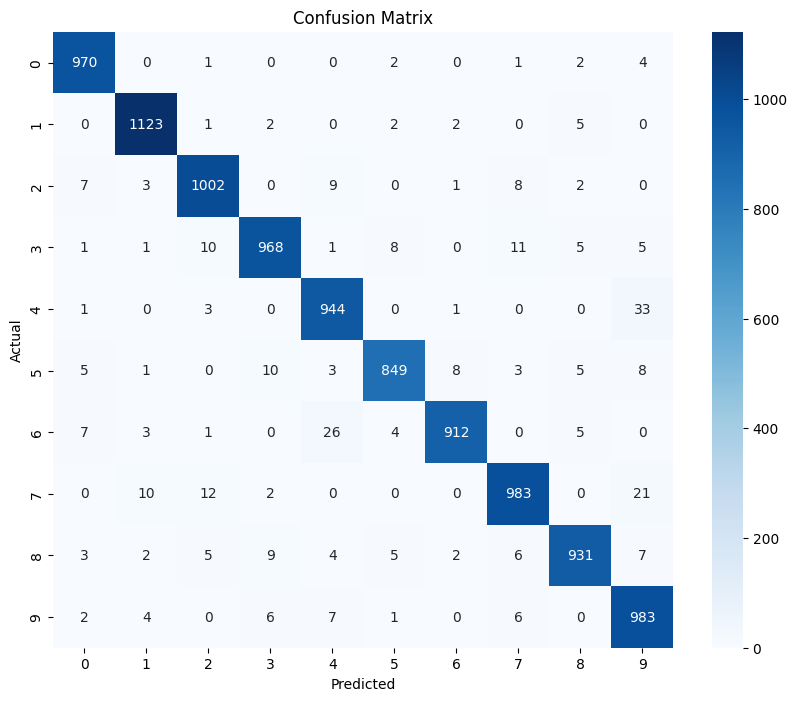

In [11]:
conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

### Misclassified examples

A sample of images the model got wrong. The title shows `true → predicted`. These are the hardest cases — often genuinely ambiguous handwriting that even humans might struggle with.

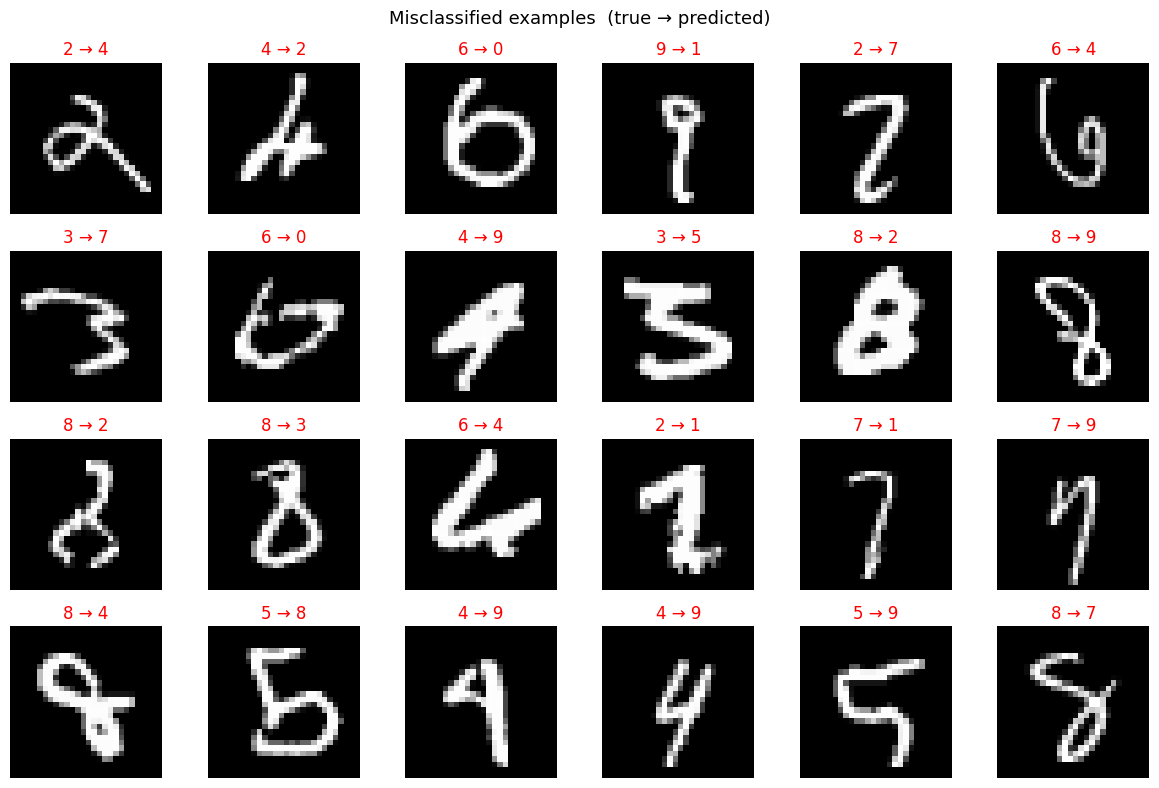

In [12]:
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for ax, (img, true, pred) in zip(axes.flatten(), misclassified[:24]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'{true} → {pred}', color='red')
    ax.axis('off')
plt.suptitle('Misclassified examples  (true → predicted)', fontsize=13)
plt.tight_layout()
plt.show()

## Save the model

Persist the trained model weights to disk using `state_dict`. This saves only the parameters (not the model architecture), which is the recommended PyTorch approach. To reload: instantiate `Net()` and call `model.load_state_dict(torch.load(...))`.

In [13]:
# torch.save(model.state_dict(), 'models/mnist.pth')